In [1]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib
matplotlib.use("Agg") #figures¯ are not sent to the Jupyter frontend #*#* (turn off if wanting to see plots in Notebook)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import pyart

from tqdm import tqdm

import os
import re
import gc


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [3]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    # print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [4]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [5]:
################################################################################

In [6]:
#DATA DESCRIPTIONS

### Data Type
# Next Generation Weather Radar (NEXRAD)

### DOI (Permanent Link)
# https://www.ncei.noaa.gov/products/radar/next-generation-weather-radar

### Summary
# The Next Generation Weather Radar (NEXRAD) system is a network of 160 high-resolution
# S-band Doppler weather radars jointly operated by the National Weather Service (NWS),
# the Federal Aviation Administration (FAA), and the U.S. Air Force. 
# The NEXRAD system detects precipitation and wind, and its data 
# can be processed to map precipitation patterns and movement.
# NCEI provides access to archived NEXRAD Level-II data and Level-III products.

### Temporal Coverage
#Selected dates (most dates available)

### Spatial Coverage

In [7]:
import math

def bounding_box(lat, lon, dist_km):
    """
    Compute bounding box corners around (lat, lon), extending dist_km in each direction,
    using Earth radius (no 111-km approximation).

    Parameters
    ----------
    lat : float
        Latitude in degrees (positive north).
    lon : float
        Longitude in degrees (positive east; negative for west).
    dist_km : float
        Distance in kilometers to extend in each direction.

    Returns
    -------
    dict
        Dictionary with keys 'SW', 'SE', 'NE', 'NW' and (lat, lon) tuples.
    """
    R = 6371.0  # Earth radius in km
    
    # Convert to radians
    lat_rad = math.radians(lat)
    
    # Degree offsets
    dlat = (dist_km / R) * (180 / math.pi)
    dlon = (dist_km / (R * math.cos(lat_rad))) * (180 / math.pi)
    
    corners = {
        "SW": (lat - dlat, lon - dlon),
        "SE": (lat - dlat, lon + dlon),
        "NE": (lat + dlat, lon + dlon),
        "NW": (lat + dlat, lon - dlon),
    }
    return corners

# Example
lat0, lon0 = 21.133, -157.180
corners = bounding_box(lat0, lon0, 250)
for name, coords in corners.items():
    print(f"{name}: {coords}")


SW: (18.884695985203173, -159.59041390266322)
SE: (18.884695985203173, -154.7695860973368)
NE: (23.381304014796825, -154.7695860973368)
NW: (23.381304014796825, -159.59041390266322)


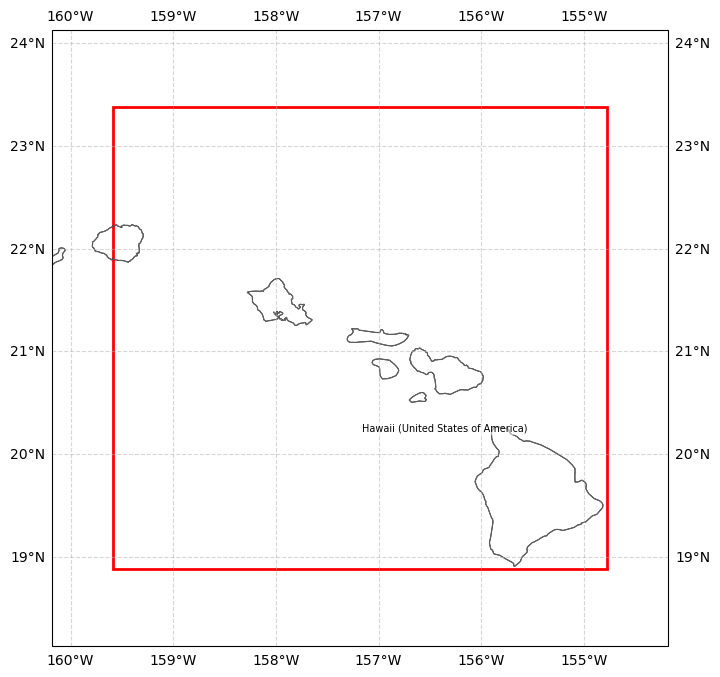

In [15]:
mapPlotting = MapPlotting(
    sw_corner=(18.88, -159.59),  # (lat_min, lon_min)
    ne_corner=(23.38, -154.77),  # (lat_max, lon_max)
    delta=3,
    fontsize=7
)
mapPlotting.PlotBoundingBox()

In [9]:
################################################################################

In [10]:
#SET UP DIRECTORIES
Campaign="Hawaii"
CaseType="MOIST"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

def GetDataDirectory(Campaign,
                     CaseType,
                     Date,
                     BaseDir="/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"):
    #old base directory: BaseDir="/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
    Data_Directory = os.path.join(BaseDir, Campaign, CaseType, Date) 
    print("Data Directory Set as:", Data_Directory, '\n')
    FileList = np.sort(ListFiles(Data_Directory))
    return Data_Directory, FileList
# [Data_Directory, FileList] = GetDataDirectory(Campaign=Campaign, CaseType=CaseType, Date=Date)

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,CaseType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/Hawaii 



In [11]:
######################################################
#PLOTTING FUNCTIONS

In [12]:
#GETTING COLORMAPS

# The Python ARM Radar Toolkit - Py-ART
# git clone https://github.com/ProjectPythia/radar-cookbook.git
# pip install arm_pyart
import pyart

import inspect
print(inspect.getsource(pyart.config.get_field_colormap))
print(pyart.config._DEFAULT_FIELD_COLORMAP.keys())


cmap_reflectivity = pyart.config.get_field_colormap('reflectivity')
# cmap_dBZ = pyart.config.get_field_colormap('dBZ') #same as reflectivity
# cmap_dbz = pyart.config.get_field_colormap('dbz') #same as reflectivity
# cmap_DBZ = pyart.config.get_field_colormap('DBZ') #same as reflectivity
cmap_viridis = plt.cm.viridis
cmap_velocity = pyart.config.get_field_colormap('velocity')
cmap_inferno = plt.cm.inferno
# import matplotlib.cm as cm
# cmap = cm.get_cmap(cmap_reflectivity)
# cmap

def get_field_colormap(field):
    """
    Return the colormap name from the configuration file for a field name.
    """
    if field in _DEFAULT_FIELD_COLORMAP:
        return _DEFAULT_FIELD_COLORMAP[field]
    else:
        import matplotlib

        # Use the default matplotlib colormap
        return matplotlib.colormaps.get_cmap("Spectral_r").name

dict_keys(['reflectivity', 'corrected_reflectivity', 'total_power', 'signal_to_noise_ratio', 'velocity', 'corrected_velocity', 'simulated_velocity', 'eastward_wind_component', 'northward_wind_component', 'vertical_wind_component', 'spectrum_width', 'normalized_coherent_power', 'differential_reflectivity', 'corrected_differential_reflectivity', 'clutter_filter_power_removed', 'cross_correlation_ratio', 'logarithmic_cross_correlation_ratio', 'differential_phase', 'unfolded_differential_phase', 'corrected_differential_phase', 'specific_differential_phase', 'corrected_specific_differential_phase', 'linear_polarization_ratio', 'linear_depol

In [13]:
def GetDateInfo(s):
    
    # Match date pattern: 8 consecutive digits starting with 20 (for 20xx dates)
    date_match = re.search(r'20\d{6}', s)
    # Match time pattern: exactly 6 digits (likely HHMMSS)
    time_match = re.search(r'(?<!\d)(\d{6})(?!\d)', s)
    
    # Format if matches are found
    if date_match and time_match:
        date_raw = date_match.group()
        time_raw = time_match.group()
    
        date_formatted = f"{date_raw[:4]}/{date_raw[4:6]}/{date_raw[6:]}"
        time_formatted = f"{time_raw[:2]}:{time_raw[2:4]}:{time_raw[4:]}"
        
        # print("Date:", date_formatted)  # 2021/12/06
        # print("Time:", time_formatted)  # 00:01:11
    else:
        print("Date or time not found.")
    return date_formatted, time_formatted

In [14]:
def GetSavePath(DataDate, OutputFolder, time_formatted):
    
    # Convert StartTime and EndTime to safe filename strings
    def clean_time(t): return t.replace(":", "_")
    
    time = clean_time(time_formatted)
    
    # Build output path
    OutputName = f"{time}.jpg"
    SavePath = os.path.join(Output_Directory, OutputFolder, DataDate)

    return SavePath, OutputName

In [15]:
def compute_latlon_from_radar(radar, sweep):
    """
    Compute latitude/longitude arrays for a given Py-ART Radar object.

    Parameters
    ----------
    radar : pyart.core.Radar
        Py-ART Radar object (from read_nexrad_archive).
    sweep : int, optional
        Sweep index to extract (default 0 = lowest elevation).

    Returns
    -------
    lat, lon : 2D arrays
        Latitude and longitude for each radar gate in the sweep.
    """
    # Extract x, y positions of gates relative to radar (meters)
    x, y, z = radar.get_gate_x_y_z(sweep)
    
    # Radar location
    radar_lat = float(radar.latitude['data'][0])
    radar_lon = float(radar.longitude['data'][0])

    # Earth radius (m)
    R = 6.371e6

    # Convert offsets to degrees
    dLat = (y / R) * (180 / np.pi)
    dLon = (x / (R * np.cos(np.deg2rad(radar_lat)))) * (180 / np.pi)

    lat = radar_lat + dLat
    lon = radar_lon + dLon

    return lat, lon


In [16]:
def plot_reflectivity_latlon(radar, lat, lon, cmap_reflectivity, plotter,
                             sweep, OutputFolder="RadarReflectivity", SaveFigure=False):
    """
    Plot radar reflectivity on a lat/lon map.

    Parameters
    ----------
    radar : pyart.core.Radar
        Radar object from Py-ART.
    lat, lon : 2D arrays
        Latitude and longitude arrays for the sweep.
    cmap_reflectivity : matplotlib colormap
        Colormap for reflectivity.
    plotter : object
        Custom MapPlotting object with PlotFromBounds() method.
    sweep : int, optional
        Sweep index (default=0).
    OutputFolder : str, optional
        Folder name for saving plots.
    """
    # Extract reflectivity field for this sweep
    start = radar.sweep_start_ray_index['data'][sweep]
    end   = radar.sweep_end_ray_index['data'][sweep] + 1
    dbz = radar.fields['reflectivity']['data'][start:end]

    # Make figure and axes
    fig, ax = plotter.PlotFromBounds(
        lat_min=lat.min(), lat_max=lat.max(),
        lon_min=lon.min(), lon_max=lon.max()
    )

    # Plot reflectivity
    cs = ax.contourf(lon, lat, dbz, cmap=cmap_reflectivity,
                     vmin=-20, vmax=60, levels=31)
    plt.colorbar(cs, ax=ax, label="Reflectivity (dBZ)")

    # Radar location
    radar_lat = float(radar.latitude['data'][0])
    radar_lon = float(radar.longitude['data'][0])
    ax.plot(radar_lon, radar_lat, "o", color="black", markersize=8)

    # Labels and title
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    
    date_formatted, time_formatted = GetDateInfo(File)
    title = f"{date_formatted} {time_formatted} UTC"
    ax.set_title(title, fontsize=14, fontweight="bold")

    if SaveFigure==True:
        # Save figure
        SavePath, OutputName = GetSavePath(DataDate=Date, OutputFolder=OutputFolder,
                                   time_formatted=time_formatted)
        os.makedirs(SavePath, exist_ok=True)
        FullOutputFile = os.path.join(SavePath, OutputName)
        plt.savefig(FullOutputFile, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved figure to: {FullOutputFile}")
    return fig, ax


In [17]:
####################################
#RUNNING FUNCTION

In [ ]:
def ProcessRadarDates(Dates):
    
    # Loop over dates
    for Date in tqdm(Dates, desc="Processing dates"):
        
        [Data_Directory, FileList] = GetDataDirectory(Campaign=Campaign, CaseType=CaseType, Date=Date)
        
        #Map Plotter
        plotter=MapPlotting(fontsize=6)
        
        for File in tqdm(FileList, desc="Processing files"):
            #------------
            #GETTING DATA
            #------------
            fname = f"/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/Hawaii/MOIST/{Date}/{File}"
            radar = pyart.io.read_nexrad_archive(fname)
            # print(radar)
            # print(radar.fields.keys())
        
            #------------
            #PLOTTING
            #------------
            sweep=0
            lat, lon = compute_latlon_from_radar(radar, sweep=sweep)
            
            # Plot with your MapPlotting wrapper
            fig, ax = plot_reflectivity_latlon(radar, lat, lon,
                                               cmap_reflectivity=cmap_reflectivity,
                                               plotter=plotter,
                                               sweep=sweep,SaveFigure=True)
        
            del radar, lat, lon
            gc.collect()

In [ ]:
####################################
#RUNNING

In [ ]:
#MOIST
Dates = ["2021-12-05", "2021-12-06", "2021-12-07"]
ProcessRadarDates(Dates)

Processing dates:   0%|          | 0/3 [00:00<?, ?it/s]

Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/Hawaii/MOIST/2021-12-05 




Processing files:   0%|          | 1/378 [00:05<37:09,  5.91s/it]

Saved figure to: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/Hawaii/MOIST/RadarReflectivity/2021-12-05/00_01_04.jpg



Processing files:   1%|          | 2/378 [00:10<33:35,  5.36s/it]

...

Saved figure to: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/Hawaii/MOIST/RadarReflectivity/2021-12-05/10_01_27.jpg



Processing files:  45%|████▍     | 170/378 [14:57<18:00,  5.20s/it]

Saved figure to: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/Hawaii/MOIST/RadarReflectivity/2021-12-05/10_04_39.jpg



Processing files:  45%|████▌     | 171/378 [15:03<18:01,  5.22s/it]

Saved figure to: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/Hawaii/MOIST/RadarReflectivity/2021-12-05/10_08_11.jpg


In [ ]:
#DRY
Dates = ["2022-08-07", "2022-08-08", "2022-08-09"]
ProcessRadarDates(Dates)

In [ ]:
################################
#COMPILING TO GIF

In [ ]:
#FUNCTIONS
# from tqdm import tqdm
# import imageio
# def make_gif_from_images(ImagesDirectory, OutputName, fps=5):
#     # Get list of all jpg files
#     files = [f for f in os.listdir(ImagesDirectory) if f.endswith(".jpg")]
#     files.sort()

#     # Read images with progress bar
#     frames = []
#     for f in tqdm(files, desc="Reading images", leave=False):
#         filepath = os.path.join(ImagesDirectory, f)
#         frames.append(imageio.v2.imread(filepath))

#     # Save in parent directory of ImagesDirectory
#     SaveDir = os.path.abspath(os.path.join(ImagesDirectory, ".."))
#     os.makedirs(SaveDir, exist_ok=True)
#     OutputPath = os.path.join(SaveDir, OutputName)

#     imageio.mimsave(OutputPath, frames, fps=fps)
#     print(f"Saved gif to {OutputPath}")

from tqdm import tqdm
import os
import imageio
from PIL import Image

def make_gif_from_images(ImagesDirectory, OutputName, fps=1, resize=None):
    """
    Create a GIF from .jpg/.png images in a directory.
    
    Parameters
    ----------
    ImagesDirectory : str
        Directory containing images.
    OutputName : str
        Name of output gif file (e.g., 'output.gif').
    fps : int
        Frames per second for gif (default = 5).
    resize : tuple, float, or None
        - (width, height): force this resolution.
        - float: scale factor (e.g., 0.5).
        - None: use first image size as reference.
    """
    # Get list of image files
    files = [f for f in os.listdir(ImagesDirectory) if f.lower().endswith((".jpg", ".png"))]
    files.sort()

    frames = []
    ref_size = None

    for f in tqdm(fsiles, desc="Reading images", leave=False):
        filepath = os.path.join(ImagesDirectory, f)
        img = Image.open(filepath).convert("RGB")

        # Set reference size from first image if resize not given
        if ref_size is None:
            if isinstance(resize, tuple):
                print("file_size is approximately ",resize[0]*resize[1]*100*1*(1000)/1e9, " MB for 100 images. ",
                      "If too high, reduce 'fps' or resize tuple")
                ref_size = resize
            elif isinstance(resize, (int, float)):
                w, h = img.size
                ref_size = (int(w * resize), int(h * resize))
            else:
                ref_size = img.size  # original size of first image

        # Resize to reference size
        img = img.resize(ref_size, Image.Resampling.LANCZOS)
        frames.append(np.array(img))

    # Save in parent directory
    SaveDir = os.path.abspath(os.path.join(ImagesDirectory, ".."))
    os.makedirs(SaveDir, exist_ok=True)
    OutputPath = os.path.join(SaveDir, OutputName)

    imageio.mimsave(OutputPath, frames, fps=fps)
    print(f"Saved gif to {OutputPath}")


In [ ]:
# RUNNING
DataTypes = ["RadarReflectivity"]
Dates = ["2021-12-05", "2021-12-06", "2021-12-07"]


Dates = []
for DataType in DataTypes:
    for Date in tqdm(Dates, desc=f"Processing {DataType}"):
        ImagesDirectory = os.path.join(Output_Directory, DataType)#, Date)
        make_gif_from_images(ImagesDirectory, OutputName=Date + "_Combined.gif", fps=2, resize=(400, 300))

In [ ]:
#########################################
#TESTING

In [ ]:
# import matplotlib.pyplot as plt
# import pyart

# # Make a display object
# display = pyart.graph.RadarMapDisplay(radar)

# fig, ax = plt.subplots(figsize=(8, 8))

# display.plot_ppi(
#     'reflectivity',
#     sweep=0,
#     vmin=-20, vmax=60,
#     cmap=cmap_reflectivity,
#     ax=ax
# )
